Model 1: y ~ a + b
Intercept:        -12.415
Coefficient of a: 8.793
Coefficient of b: 8.432

Model 2: y ~ a + b + a:b
Intercept:        2.052
Coefficient of a: 1.093
Coefficient of b: 1.111
Coefficient a:b:  3.902

Fit quality on same data
MSE for y ~ a + b:       33.061
MSE for y ~ a + b + a:b: 3.866


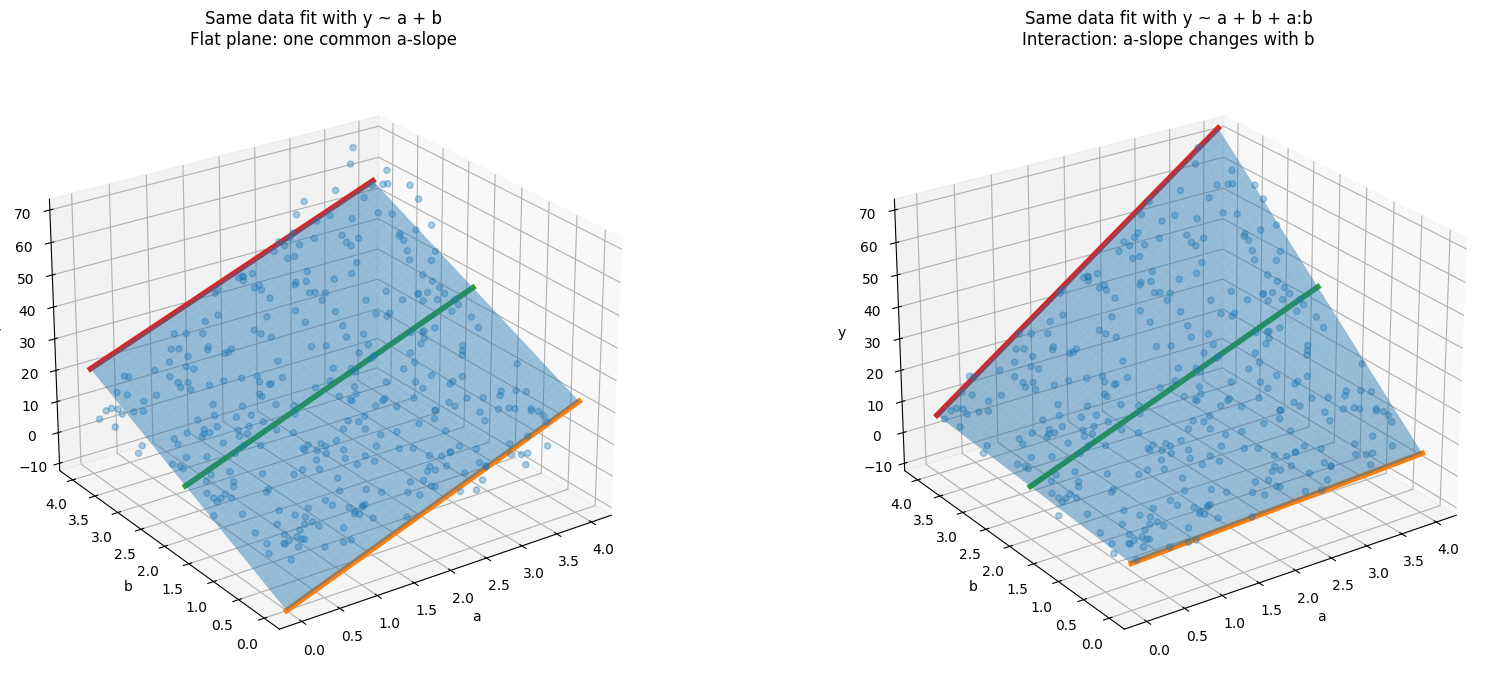


Implied slopes in the a-direction

For y ~ a + b:
b = 0: slope in a = 8.793
b = 2: slope in a = 8.793
b = 4: slope in a = 8.793

For y ~ a + b + a:b:
b = 0: slope in a = 1.093
b = 2: slope in a = 8.896
b = 4: slope in a = 16.700


In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# -----------------------------
# Helper: fit OLS with numpy
# -----------------------------
def ols_fit(X, y):
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return beta

# -----------------------------
# Create ONE mock dataset
# -----------------------------
n = 350

a = np.random.uniform(0, 4, n)
b = np.random.uniform(0, 4, n)

noise = np.random.normal(0, 2.0, n)

# TRUE data-generating process has a strong interaction
#
# y = 2 + 1a + 1b + 4ab + noise
#
# So the true slope in a is:
# dy/da = 1 + 4b
#
# b = 0 -> slope in a = 1
# b = 2 -> slope in a = 9
# b = 4 -> slope in a = 17
y = 2 + 1*a + 1*b + 4*a*b + noise

# -----------------------------
# Fit model 1: y ~ a + b
# -----------------------------
X_additive = np.column_stack([
    np.ones(n),
    a,
    b
])

beta_additive = ols_fit(X_additive, y)

# -----------------------------
# Fit model 2: y ~ a + b + a:b
# -----------------------------
X_interaction = np.column_stack([
    np.ones(n),
    a,
    b,
    a*b
])

beta_interaction = ols_fit(X_interaction, y)

# -----------------------------
# Print fitted coefficients
# -----------------------------
print("Model 1: y ~ a + b")
print(f"Intercept:        {beta_additive[0]:.3f}")
print(f"Coefficient of a: {beta_additive[1]:.3f}")
print(f"Coefficient of b: {beta_additive[2]:.3f}")

print("\nModel 2: y ~ a + b + a:b")
print(f"Intercept:        {beta_interaction[0]:.3f}")
print(f"Coefficient of a: {beta_interaction[1]:.3f}")
print(f"Coefficient of b: {beta_interaction[2]:.3f}")
print(f"Coefficient a:b:  {beta_interaction[3]:.3f}")

# -----------------------------
# Create grid for fitted surfaces
# -----------------------------
a_grid = np.linspace(0, 4, 80)
b_grid = np.linspace(0, 4, 80)

A, B = np.meshgrid(a_grid, b_grid)

Y_hat_additive = (
    beta_additive[0]
    + beta_additive[1] * A
    + beta_additive[2] * B
)

Y_hat_interaction = (
    beta_interaction[0]
    + beta_interaction[1] * A
    + beta_interaction[2] * B
    + beta_interaction[3] * A * B
)

# Fitted values at the actual data points
y_hat_additive_points = (
    beta_additive[0]
    + beta_additive[1] * a
    + beta_additive[2] * b
)

y_hat_interaction_points = (
    beta_interaction[0]
    + beta_interaction[1] * a
    + beta_interaction[2] * b
    + beta_interaction[3] * a * b
)

mse_additive = np.mean((y - y_hat_additive_points) ** 2)
mse_interaction = np.mean((y - y_hat_interaction_points) ** 2)

print("\nFit quality on same data")
print(f"MSE for y ~ a + b:       {mse_additive:.3f}")
print(f"MSE for y ~ a + b + a:b: {mse_interaction:.3f}")

# -----------------------------
# Fixed b slices
# -----------------------------
b_slices = [0, 2, 4]

# Shared z limits for fair comparison
z_min = min(y.min(), Y_hat_additive.min(), Y_hat_interaction.min())
z_max = max(y.max(), Y_hat_additive.max(), Y_hat_interaction.max())

# -----------------------------
# Side-by-side 3D plots
# -----------------------------
fig = plt.figure(figsize=(18, 7))

# ======================================================
# Plot 1: same data, additive model
# ======================================================
ax1 = fig.add_subplot(121, projection="3d")

ax1.scatter(a, b, y, alpha=0.35, label="same data points")
ax1.plot_surface(A, B, Y_hat_additive, alpha=0.45)

for b_fixed in b_slices:
    y_slice = (
        beta_additive[0]
        + beta_additive[1] * a_grid
        + beta_additive[2] * b_fixed
    )

    ax1.plot(
        a_grid,
        np.full_like(a_grid, b_fixed),
        y_slice,
        linewidth=4,
        label=f"b = {b_fixed}"
    )

ax1.set_title(
    "Same data fit with y ~ a + b\n"
    "Flat plane: one common a-slope"
)
ax1.set_xlabel("a")
ax1.set_ylabel("b")
ax1.set_zlabel("y")
ax1.set_zlim(z_min, z_max)
ax1.view_init(elev=25, azim=-125)

# ======================================================
# Plot 2: same data, interaction model
# ======================================================
ax2 = fig.add_subplot(122, projection="3d")

ax2.scatter(a, b, y, alpha=0.35, label="same data points")
ax2.plot_surface(A, B, Y_hat_interaction, alpha=0.45)

for b_fixed in b_slices:
    y_slice = (
        beta_interaction[0]
        + beta_interaction[1] * a_grid
        + beta_interaction[2] * b_fixed
        + beta_interaction[3] * a_grid * b_fixed
    )

    ax2.plot(
        a_grid,
        np.full_like(a_grid, b_fixed),
        y_slice,
        linewidth=4,
        label=f"b = {b_fixed}"
    )

ax2.set_title(
    "Same data fit with y ~ a + b + a:b\n"
    "Interaction: a-slope changes with b"
)
ax2.set_xlabel("a")
ax2.set_ylabel("b")
ax2.set_zlabel("y")
ax2.set_zlim(z_min, z_max)
ax2.view_init(elev=25, azim=-125)

plt.tight_layout()
plt.show()

# -----------------------------
# Print implied slopes in a-direction
# -----------------------------
print("\nImplied slopes in the a-direction")

print("\nFor y ~ a + b:")
for b_fixed in b_slices:
    slope_a = beta_additive[1]
    print(f"b = {b_fixed}: slope in a = {slope_a:.3f}")

print("\nFor y ~ a + b + a:b:")
for b_fixed in b_slices:
    slope_a = beta_interaction[1] + beta_interaction[3] * b_fixed
    print(f"b = {b_fixed}: slope in a = {slope_a:.3f}")